## Agentic RAG (Tool Based)

In [1]:
import os
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_community.vectorstores import Chroma

### Document Loader

In [2]:
def load_documents(data_folder):
    documents = []
    ids = []
    
    for file in os.listdir(data_folder):
        path = os.path.join(data_folder, file)
        with open(path, 'r') as f:
            text = f.read()
        
        documents.append(text)
        ids.append(file)
    return documents, ids

### Create LLM

In [3]:
llm = ChatOpenAI(api_key=os.getenv('OPENAI_SECRET_KEY'), model='gpt-4o-mini')
embedding_model = OpenAIEmbeddings(api_key=os.getenv('OPENAI_SECRET_KEY'), model='text-embedding-3-small')

llm, embedding_model

(ChatOpenAI(profile={'max_input_tokens': 128000, 'max_output_tokens': 16384, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'structured_output': True, 'image_url_inputs': True, 'pdf_inputs': True, 'pdf_tool_message': True, 'image_tool_message': True, 'tool_choice': True}, client=<openai.resources.chat.completions.completions.Completions object at 0x00000226B26397D0>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x00000226B2C5ACD0>, root_client=<openai.OpenAI object at 0x00000226B210A150>, root_async_client=<openai.AsyncOpenAI object at 0x00000226B272D590>, model_name='gpt-4o-mini', model_kwargs={}, openai_api_key=SecretStr('**********'), stream_usage=True),
 OpenAIEmbeddings(client=<openai.resources.embeddings.Embeddings object at 0x00000226B2C5B210>, async_clien

### Create VectorDB

In [5]:
data_folder = '../data'

documents, ids = load_documents(data_folder=data_folder)

documents, ids

(['AcmeTech Solutions Code of Conduct\n\nEmployees must maintain professional behavior at all times.\n\nHarassment, discrimination, or unethical conduct will not be tolerated.',
  'AcmeTech Solutions IT Security Policy\n\nEmployees must not share their passwords with anyone.\n\nAll systems must be locked when unattended.\n\nSensitive data must be stored securely and encrypted where appropriate.',
  'AcmeTech Solutions Leave Policy\n\nAll full-time employees are entitled to 20 days of paid annual leave per calendar year.\n\nLeave requests must be submitted at least two weeks in advance.\n\nUnused leave may not be carried over to the next year unless approved.',
  "AcmeTech Solutions Remote Work Policy\n\nEmployees are allowed to work remotely up to 2 days per week.\n\nRemote work must be approved by the employee's manager.\n\nEmployees must ensure a secure and productive work environment while working remotely."],
 ['code_of_conduct.txt',
  'it_security_policy.txt',
  'leave_policy.txt'

In [18]:
vector_db = Chroma.from_texts(
    texts=documents,
    embedding=embedding_model,
    ids=ids,
    persist_directory='../agentic_rag_db',
    collection_metadata={'hnsw:space': 'cosine'}
)

retriever = vector_db.as_retriever(search_kwargs={'k': 2})

vector_db, retriever

(<langchain_community.vectorstores.chroma.Chroma at 0x226b4b6ce50>,
 VectorStoreRetriever(tags=['Chroma', 'OpenAIEmbeddings'], vectorstore=<langchain_community.vectorstores.chroma.Chroma object at 0x00000226B4B6CE50>, search_kwargs={'k': 2}))

In [19]:
retriever.invoke('work from home')

[Document(metadata={}, page_content="AcmeTech Solutions Remote Work Policy\n\nEmployees are allowed to work remotely up to 2 days per week.\n\nRemote work must be approved by the employee's manager.\n\nEmployees must ensure a secure and productive work environment while working remotely."),
 Document(metadata={}, page_content='AcmeTech Solutions Leave Policy\n\nAll full-time employees are entitled to 20 days of paid annual leave per calendar year.\n\nLeave requests must be submitted at least two weeks in advance.\n\nUnused leave may not be carried over to the next year unless approved.')]

### Tool

In [22]:
def document_retriever(query):
    docs = retriever.invoke(query)
    context = '\n'.join([doc.page_content for doc in docs])
    return context

In [23]:
document_retriever('work from home')

"AcmeTech Solutions Remote Work Policy\n\nEmployees are allowed to work remotely up to 2 days per week.\n\nRemote work must be approved by the employee's manager.\n\nEmployees must ensure a secure and productive work environment while working remotely.\nAcmeTech Solutions Leave Policy\n\nAll full-time employees are entitled to 20 days of paid annual leave per calendar year.\n\nLeave requests must be submitted at least two weeks in advance.\n\nUnused leave may not be carried over to the next year unless approved."

### Agentic RAG

In [26]:
def agentic_rag(query):
    print('\nUser Query:\n', query)
    
    # Initial Retrieval
    context = document_retriever(query)
    print('\nInitial Context:\n', context)
    
    # Agent Decision
    decision_prompt = f'''You are an intelligent assistant.
Question:
{query}

Context:
{context}

Do you have enough information (context) to answer the query?
Answer only YES or NO'''

    decision = llm.invoke(decision_prompt).content.strip()
    print('\nAgent Decision: ', decision)
    
    if "no" in decision.lower():
        refine_prompt = f'''Rewrite the given query to retrieve better/more relevant information.
Original Query:
{query}
'''

        refined_query = llm.invoke(refine_prompt).content
        print('\nRefined Query:\n', refined_query)
        
        context = document_retriever(refined_query)
        print('\nUpdated Context:\n',context)
        
    # Final Answer (Generation)
    final_prompt = f'''Answer the following query using the given context only. 
If the given context is not enough or relevant, then say you don't have enough information to answer the query. 
If you don't know the answer, just say that you don't know, don't try to make up an answer.

Query:
{query}

Context:
{context}
'''

    answer = llm.invoke(final_prompt).content
    print('\nAnswer:\n', answer)
    
    return answer

### Testing

In [29]:
agentic_rag('How many days of leave in a week is allowed for an employee?')


User Query:
 How many days of leave in a week is allowed for an employee?

Initial Context:
 AcmeTech Solutions Leave Policy

All full-time employees are entitled to 20 days of paid annual leave per calendar year.

Leave requests must be submitted at least two weeks in advance.

Unused leave may not be carried over to the next year unless approved.
AcmeTech Solutions Remote Work Policy

Employees are allowed to work remotely up to 2 days per week.

Remote work must be approved by the employee's manager.

Employees must ensure a secure and productive work environment while working remotely.

Agent Decision:  NO

Refined Query:
 What is the maximum number of leave days an employee can take per week according to company policy?

Updated Context:
 AcmeTech Solutions Leave Policy

All full-time employees are entitled to 20 days of paid annual leave per calendar year.

Leave requests must be submitted at least two weeks in advance.

Unused leave may not be carried over to the next year unle

"I don't have enough information to answer the query."

In [30]:
agentic_rag('How many days of leave in a year is allowed for an employee?')


User Query:
 How many days of leave in a year is allowed for an employee?

Initial Context:
 AcmeTech Solutions Leave Policy

All full-time employees are entitled to 20 days of paid annual leave per calendar year.

Leave requests must be submitted at least two weeks in advance.

Unused leave may not be carried over to the next year unless approved.
AcmeTech Solutions Remote Work Policy

Employees are allowed to work remotely up to 2 days per week.

Remote work must be approved by the employee's manager.

Employees must ensure a secure and productive work environment while working remotely.

Agent Decision:  YES

Answer:
 All full-time employees are entitled to 20 days of paid annual leave per calendar year.


'All full-time employees are entitled to 20 days of paid annual leave per calendar year.'

In [32]:
agentic_rag('What is the capital of India?')


User Query:
 What is the capital of India?

Initial Context:
 AcmeTech Solutions IT Security Policy

Employees must not share their passwords with anyone.

All systems must be locked when unattended.

Sensitive data must be stored securely and encrypted where appropriate.
AcmeTech Solutions Leave Policy

All full-time employees are entitled to 20 days of paid annual leave per calendar year.

Leave requests must be submitted at least two weeks in advance.

Unused leave may not be carried over to the next year unless approved.

Agent Decision:  NO

Refined Query:
 What is the capital city of India, and can you provide some interesting facts about it?

Updated Context:
 AcmeTech Solutions IT Security Policy

Employees must not share their passwords with anyone.

All systems must be locked when unattended.

Sensitive data must be stored securely and encrypted where appropriate.
AcmeTech Solutions Leave Policy

All full-time employees are entitled to 20 days of paid annual leave per calend

"I don't have enough information to answer the query."

## Langgraph

In [34]:
# Langchain - AI Pipelines
# Langgraph - Agents

In [36]:
# %pip install langgraph

In [38]:
# Step-1 -> Fetch Documents
# Step-2 -> Create chunks if required
# Step-3 -> Create embeddings and store in a DB

In [37]:
from langgraph.graph import StateGraph
from typing import TypedDict

### Step 4: Define State (It is the memory of the agent)

In [52]:
class AgentState(TypedDict):
    query: str
    context: str
    decision: str
    answer: str
    
AgentState

__main__.AgentState

### Step 5: Create Nodes

#### Node 1: Retrieval

In [44]:
def retrieve_node(state):
    query = state['query']
    docs = retriever.invoke(query)
    context = '\n'.join([doc.page_content for doc in docs])
    print('\n1. Retrieve Node:')
    print(context)
    
    return {'context': context}

#### Node 2: Decision

In [46]:
def decision_node(state):
    query = state['query']
    context = state['context']
    decision_prompt = f'''You are an intelligent assistant.
Question:
{query}

Context:
{context}

Do you have enough information (context) to answer the query from the given context?
Answer only YES or NO'''

    decision = llm.invoke(decision_prompt).content.strip()
    print('\n2. Decision Node:')
    print(decision)
    
    return {'decision': decision}

#### Node 3: Query Refinement

In [47]:
def query_refinement_node(state):
    query = state['query']
    refine_prompt = f'''Rewrite the given query to retrieve better/more relevant information.
Original Query:
{query}
'''
    refined_query = llm.invoke(refine_prompt).content.strip()
    print('\n3. Query Refinement Node:')
    print(refined_query)
    
    return {'query': query}

#### Node 4: Generation (Final Answer)

In [66]:
def generation_node(state):
    query = state['query']
    context = state['context']
    final_prompt = f'''Answer the following query using the given context only. 
If the given context is not enough or relevant, then say you don't have enough information to answer the query. 
If you don't know the answer, just say that you don't know, don't try to make up an answer.

Query:
{query}

Context:
{context}
'''

    answer = llm.invoke(final_prompt).content
    print('\n4. Generation Node:')
    print(answer)
    
    return {'answer': answer}

#### Conditional Logic

In [51]:
def should_refine(state):
    decision = state['decision']
    if 'no' in decision.lower():
        return 'refine'
    else:
        return 'generate'

### Step 6: Create Graph

In [78]:
# Step 1: Add State
graph = StateGraph(AgentState) # Memory
graph

In [79]:
# Step 2: Add nodes
graph.add_node('retrieve', retrieve_node)
graph.add_node('decision', decision_node)
graph.add_node('refine', query_refinement_node)
graph.add_node('generate', generation_node)

graph

In [80]:
# Step 3: Flow
graph.set_entry_point('retrieve')

graph.add_edge('retrieve', 'decision')

graph.add_conditional_edges('decision',
                            should_refine,
                            {'refine': 'refine',
                             'generate': 'generate'})

graph.add_edge('refine', 'retrieve')
graph.add_edge('generate', '__end__')

# graph.set_finish_point('generate')

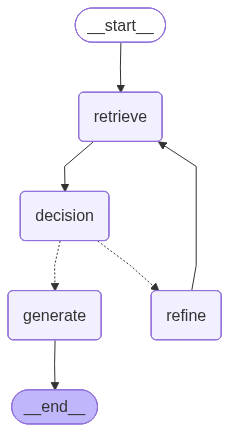

In [81]:
agent = graph.compile()
agent

### Testing

In [76]:
res = agent.invoke({'query': 'explain leave policy'})


1. Retrieve Node:
AcmeTech Solutions Leave Policy

All full-time employees are entitled to 20 days of paid annual leave per calendar year.

Leave requests must be submitted at least two weeks in advance.

Unused leave may not be carried over to the next year unless approved.
AcmeTech Solutions Remote Work Policy

Employees are allowed to work remotely up to 2 days per week.

Remote work must be approved by the employee's manager.

Employees must ensure a secure and productive work environment while working remotely.

2. Decision Node:
YES

4. Generation Node:
The leave policy at AcmeTech Solutions states that all full-time employees are entitled to 20 days of paid annual leave per calendar year. Leave requests must be submitted at least two weeks in advance, and unused leave may not be carried over to the next year unless approved.


In [82]:
res = agent.invoke({'query': 'what is the capital of India?'})


1. Retrieve Node:
AcmeTech Solutions IT Security Policy

Employees must not share their passwords with anyone.

All systems must be locked when unattended.

Sensitive data must be stored securely and encrypted where appropriate.
AcmeTech Solutions Leave Policy

All full-time employees are entitled to 20 days of paid annual leave per calendar year.

Leave requests must be submitted at least two weeks in advance.

Unused leave may not be carried over to the next year unless approved.

2. Decision Node:
NO

3. Query Refinement Node:
What is the name of the capital city of India?

1. Retrieve Node:
AcmeTech Solutions IT Security Policy

Employees must not share their passwords with anyone.

All systems must be locked when unattended.

Sensitive data must be stored securely and encrypted where appropriate.
AcmeTech Solutions Leave Policy

All full-time employees are entitled to 20 days of paid annual leave per calendar year.

Leave requests must be submitted at least two weeks in advance.


APIConnectionError: Connection error.